=== AHP (Analytic Hierarchy Process) Calculator with Visualizations ===

Enter the number of indicators/criteria: 13
Enter name for indicator 1: Geology
Enter name for indicator 2: MaxDef
Enter name for indicator 3: MeanDef
Enter name for indicator 4: Elevation
Enter name for indicator 5: Slope
Enter name for indicator 6: Aspect
Enter name for indicator 7: Soil
Enter name for indicator 8: Rainfall
Enter name for indicator 9: NDVI
Enter name for indicator 10: LULC
Enter name for indicator 11: DistRiver
Enter name for indicator 12: DistFault
Enter name for indicator 13: DistRoad

Now enter pairwise comparisons using Saaty's scale:
 1 = equal importance
 3 = moderate importance
 5 = strong importance
 7 = very strong importance
 9 = extreme importance
Use fractions (e.g., 1/3) if the second indicator is more important.

How important is 'Geology' compared to 'MaxDef'? (1-9 or fraction, e.g., 1/3): 1/2
How important is 'Geology' compared to 'MeanDef'? (1-9 or fraction, e.g., 1/3): 1/2
How 

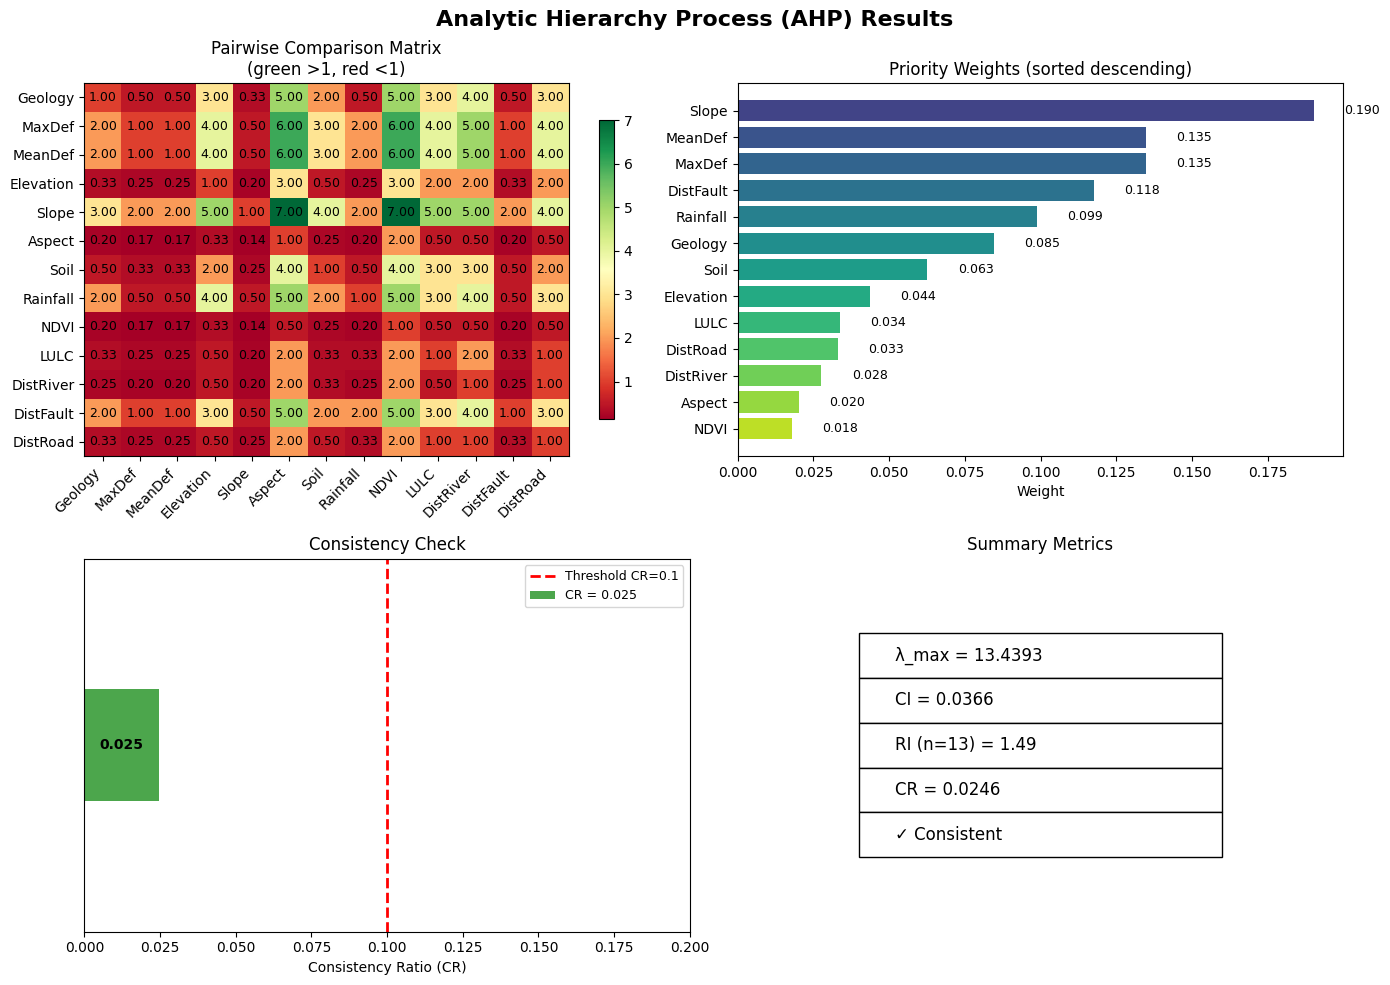

In [1]:
#!/usr/bin/env python3
"""
AHP Calculator with Creative Visualizations
-------------------------------------------
Interactive tool for Analytic Hierarchy Process (AHP) that:
- Collects pairwise comparisons using Saaty's scale.
- Computes priority weights, λ_max, Consistency Index (CI), and Consistency Ratio (CR).
- Visualizes the results with heatmaps, bar charts, and a consistency gauge.
"""

import sys

# Optional imports for visualization
try:
    import matplotlib.pyplot as plt
    import matplotlib
    import numpy as np
    from matplotlib.patches import Rectangle
    VISUAL_AVAILABLE = True
except ImportError:
    VISUAL_AVAILABLE = False
    print("INFO: matplotlib not installed. Visualizations will be skipped.")
    print("      Install with: pip install matplotlib numpy")

def get_float_input(prompt):
    """Get a positive float from the user, accepting decimals or fractions like 1/3."""
    while True:
        user_input = input(prompt).strip()
        if not user_input:
            continue
        if '/' in user_input:
            parts = user_input.split('/')
            if len(parts) == 2:
                try:
                    num = float(parts[0])
                    den = float(parts[1])
                    if den == 0:
                        print("Denominator cannot be zero. Please try again.")
                        continue
                    value = num / den
                except ValueError:
                    print("Invalid fraction. Please enter a number (e.g., 3, 0.2, 1/3).")
                    continue
            else:
                print("Invalid fraction format. Use e.g., 1/3.")
                continue
        else:
            try:
                value = float(user_input)
            except ValueError:
                print("Invalid number. Please enter a number (e.g., 3, 0.2, 1/3).")
                continue

        if value <= 0:
            print("Please enter a positive value.")
        else:
            return value

def visualize_results(matrix, names, weights, lambda_max, CI, RI, CR):
    """Create a multi-panel visualization of the AHP results."""
    if not VISUAL_AVAILABLE:
        print("Visualizations require matplotlib and numpy. Skipping.")
        return

    n = len(names)
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle('Analytic Hierarchy Process (AHP) Results', fontsize=16, fontweight='bold')

    # 1. Heatmap of the pairwise comparison matrix
    ax1 = fig.add_subplot(2, 2, 1)
    # Create a matrix with 1s on diagonal, but we'll show the full matrix
    # Use a logarithmic colormap because ratios can be large; but we'll use a diverging colormap centered at 1
    # Clip values for better visualization? Better to show actual values.
    im = ax1.imshow(matrix, cmap='RdYlGn', interpolation='nearest', aspect='auto',
                   vmin=min(1, np.min(matrix)), vmax=max(1, np.max(matrix)))
    ax1.set_xticks(range(n))
    ax1.set_yticks(range(n))
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=10)
    ax1.set_yticklabels(names, fontsize=10)
    ax1.set_title('Pairwise Comparison Matrix\n(green >1, red <1)', fontsize=12)

    # Add text annotations
    for i in range(n):
        for j in range(n):
            text = ax1.text(j, i, f'{matrix[i][j]:.2f}',
                           ha='center', va='center', color='black', fontsize=9)
    plt.colorbar(im, ax=ax1, shrink=0.8)

    # 2. Horizontal bar chart of weights (sorted)
    ax2 = fig.add_subplot(2, 2, 2)
    sorted_indices = np.argsort(weights)[::-1]  # descending
    sorted_names = [names[i] for i in sorted_indices]
    sorted_weights = [weights[i] for i in sorted_indices]
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n))
    y_pos = np.arange(n)
    ax2.barh(y_pos, sorted_weights, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(sorted_names, fontsize=10)
    ax2.invert_yaxis()  # highest weight on top
    ax2.set_xlabel('Weight')
    ax2.set_title('Priority Weights (sorted descending)', fontsize=12)
    for i, v in enumerate(sorted_weights):
        ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    # 3. Consistency gauge (horizontal bar with threshold)
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.set_xlim(0, max(0.2, CR*1.2))  # show a bit beyond CR or 0.2
    ax3.set_ylim(0, 1)
    ax3.axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Threshold CR=0.1')
    # Draw a bar for CR
    bar_color = 'green' if CR < 0.1 else 'red'
    ax3.barh(0.5, CR, height=0.3, color=bar_color, alpha=0.7, label=f'CR = {CR:.3f}')
    ax3.set_yticks([])
    ax3.set_xlabel('Consistency Ratio (CR)')
    ax3.set_title('Consistency Check', fontsize=12)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.text(CR/2, 0.5, f'{CR:.3f}', ha='center', va='center', fontweight='bold')

    # 4. Summary table of key metrics
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.axis('tight')
    ax4.axis('off')
    cell_text = [[f'λ_max = {lambda_max:.4f}'],
                 [f'CI = {CI:.4f}'],
                 [f'RI (n={n}) = {RI:.2f}'],
                 [f'CR = {CR:.4f}'],
                 ['✓ Consistent' if CR < 0.1 else '✗ Inconsistent']]
    table = ax4.table(cellText=cell_text, loc='center', cellLoc='left',
                      colWidths=[0.5], bbox=[0.2, 0.2, 0.6, 0.6])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    ax4.set_title('Summary Metrics', fontsize=12)

    plt.tight_layout()
    plt.show()

def ahp_calculation():
    """Main AHP calculation routine with optional visualization."""
    print("=== AHP (Analytic Hierarchy Process) Calculator with Visualizations ===\n")

    # Number of indicators
    while True:
        try:
            n = int(input("Enter the number of indicators/criteria: "))
            if n < 1:
                print("Number must be at least 1.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter an integer.")

    if n == 1:
        print("\nOnly one indicator – its weight is 1.0. Consistency is trivial.")
        if VISUAL_AVAILABLE and input("Show simple visualization? (y/n): ").lower().startswith('y'):
            # Simple bar for single indicator
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4,4))
            plt.bar(['Indicator'], [1.0], color='skyblue')
            plt.ylim(0,1)
            plt.title('Single Indicator Weight = 1.0')
            plt.show()
        sys.exit(0)

    # Names of indicators
    names = []
    for i in range(n):
        name = input(f"Enter name for indicator {i+1}: ").strip()
        if not name:
            name = f"Indicator {i+1}"   # default name
        names.append(name)

    # Initialize pairwise comparison matrix with 1s on diagonal
    matrix = [[1.0] * n for _ in range(n)]

    print("\nNow enter pairwise comparisons using Saaty's scale:")
    print(" 1 = equal importance")
    print(" 3 = moderate importance")
    print(" 5 = strong importance")
    print(" 7 = very strong importance")
    print(" 9 = extreme importance")
    print("Use fractions (e.g., 1/3) if the second indicator is more important.\n")

    for i in range(n):
        for j in range(i+1, n):
            prompt = (f"How important is '{names[i]}' compared to '{names[j]}'? "
                      f"(1-9 or fraction, e.g., 1/3): ")
            value = get_float_input(prompt)
            matrix[i][j] = value
            matrix[j][i] = 1.0 / value

    # Print the matrix
    print("\nPairwise Comparison Matrix:")
    print(" " * 12 + " ".join(f"{name:>12}" for name in names))
    for i in range(n):
        row_str = f"{names[i]:<12}" + " ".join(f"{matrix[i][j]:12.4f}" for j in range(n))
        print(row_str)

    # Step 1: Normalize the matrix (divide each element by its column sum)
    col_sums = [sum(matrix[i][j] for i in range(n)) for j in range(n)]
    norm_matrix = [[matrix[i][j] / col_sums[j] for j in range(n)] for i in range(n)]

    # Step 2: Priority vector = row averages of normalized matrix
    weights = [sum(norm_matrix[i]) / n for i in range(n)]

    # Step 3: Calculate lambda max (principal eigenvalue approximation)
    weighted_sum = [sum(matrix[i][j] * weights[j] for j in range(n)) for i in range(n)]
    lambda_max = sum(weighted_sum[i] / weights[i] for i in range(n)) / n

    # Step 4: Consistency Index (CI) and Consistency Ratio (CR)
    CI = (lambda_max - n) / (n - 1)

    # Random Index (RI) values for n = 1 to 10 (standard AHP values)
    RI_dict = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.9, 5: 1.12,
               6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    RI = RI_dict.get(n, 1.49)  # default for n > 10 is an approximation; could warn

    CR = CI / RI if RI != 0 else 0.0

    # Output results
    print("\n=== Results ===")
    print("Priority Vector (Weights):")
    for name, w in zip(names, weights):
        print(f"  {name}: {w:.4f}")

    print(f"\nlambda_max = {lambda_max:.4f}")
    print(f"Consistency Index (CI) = {CI:.4f}")
    print(f"Random Index (RI) for n={n} = {RI:.2f}")
    print(f"Consistency Ratio (CR) = {CR:.4f}")

    if CR < 0.1:
        print("The judgments are CONSISTENT (CR < 0.1).")
    else:
        print("WARNING: The judgments are INCONSISTENT (CR >= 0.1). Consider revising the comparisons.")

    # Ask for visualization
    if VISUAL_AVAILABLE:
        viz = input("\nWould you like to see visualizations? (y/n): ").strip().lower()
        if viz.startswith('y'):
            visualize_results(matrix, names, weights, lambda_max, CI, RI, CR)
    else:
        print("\nInstall matplotlib and numpy for visualizations.")

if __name__ == "__main__":
    ahp_calculation()


=== AHP (Analytic Hierarchy Process) Calculator with Visualizations ===

Enter the number of indicators/criteria: 11
Enter name for indicator 1: Curvature
Enter name for indicator 2: TWI
Enter name for indicator 3: Elevation
Enter name for indicator 4: Slope
Enter name for indicator 5: Soil
Enter name for indicator 6: Rainfall
Enter name for indicator 7: NDVI
Enter name for indicator 8: LULC
Enter name for indicator 9: DistRiver
Enter name for indicator 10: SPI
Enter name for indicator 11: DistRoad

Now enter pairwise comparisons using Saaty's scale:
 1 = equal importance
 3 = moderate importance
 5 = strong importance
 7 = very strong importance
 9 = extreme importance
Use fractions (e.g., 1/3) if the second indicator is more important.

How important is 'Curvature' compared to 'TWI'? (1-9 or fraction, e.g., 1/3): 1/3
How important is 'Curvature' compared to 'Elevation'? (1-9 or fraction, e.g., 1/3): 1/5
How important is 'Curvature' compared to 'Slope'? (1-9 or fraction, e.g., 1/3): 1

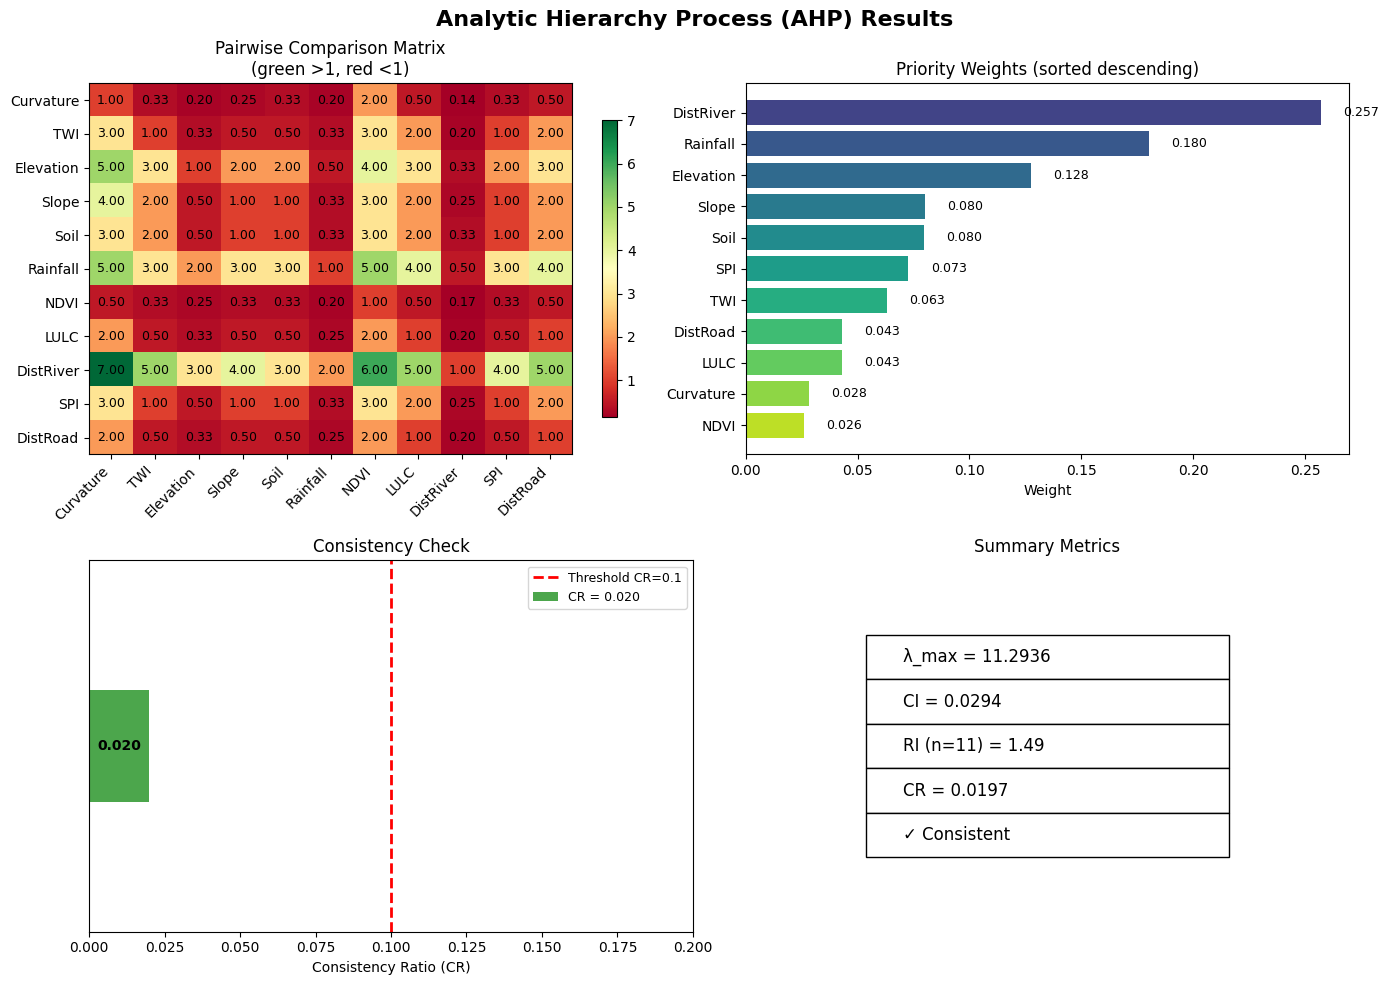

In [2]:
#!/usr/bin/env python3
"""
AHP Calculator with Creative Visualizations
-------------------------------------------
Interactive tool for Analytic Hierarchy Process (AHP) that:
- Collects pairwise comparisons using Saaty's scale.
- Computes priority weights, λ_max, Consistency Index (CI), and Consistency Ratio (CR).
- Visualizes the results with heatmaps, bar charts, and a consistency gauge.
"""

import sys

# Optional imports for visualization
try:
    import matplotlib.pyplot as plt
    import matplotlib
    import numpy as np
    from matplotlib.patches import Rectangle
    VISUAL_AVAILABLE = True
except ImportError:
    VISUAL_AVAILABLE = False
    print("INFO: matplotlib not installed. Visualizations will be skipped.")
    print("      Install with: pip install matplotlib numpy")

def get_float_input(prompt):
    """Get a positive float from the user, accepting decimals or fractions like 1/3."""
    while True:
        user_input = input(prompt).strip()
        if not user_input:
            continue
        if '/' in user_input:
            parts = user_input.split('/')
            if len(parts) == 2:
                try:
                    num = float(parts[0])
                    den = float(parts[1])
                    if den == 0:
                        print("Denominator cannot be zero. Please try again.")
                        continue
                    value = num / den
                except ValueError:
                    print("Invalid fraction. Please enter a number (e.g., 3, 0.2, 1/3).")
                    continue
            else:
                print("Invalid fraction format. Use e.g., 1/3.")
                continue
        else:
            try:
                value = float(user_input)
            except ValueError:
                print("Invalid number. Please enter a number (e.g., 3, 0.2, 1/3).")
                continue

        if value <= 0:
            print("Please enter a positive value.")
        else:
            return value

def visualize_results(matrix, names, weights, lambda_max, CI, RI, CR):
    """Create a multi-panel visualization of the AHP results."""
    if not VISUAL_AVAILABLE:
        print("Visualizations require matplotlib and numpy. Skipping.")
        return

    n = len(names)
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle('Analytic Hierarchy Process (AHP) Results', fontsize=16, fontweight='bold')

    # 1. Heatmap of the pairwise comparison matrix
    ax1 = fig.add_subplot(2, 2, 1)
    # Create a matrix with 1s on diagonal, but we'll show the full matrix
    # Use a logarithmic colormap because ratios can be large; but we'll use a diverging colormap centered at 1
    # Clip values for better visualization? Better to show actual values.
    im = ax1.imshow(matrix, cmap='RdYlGn', interpolation='nearest', aspect='auto',
                   vmin=min(1, np.min(matrix)), vmax=max(1, np.max(matrix)))
    ax1.set_xticks(range(n))
    ax1.set_yticks(range(n))
    ax1.set_xticklabels(names, rotation=45, ha='right', fontsize=10)
    ax1.set_yticklabels(names, fontsize=10)
    ax1.set_title('Pairwise Comparison Matrix\n(green >1, red <1)', fontsize=12)

    # Add text annotations
    for i in range(n):
        for j in range(n):
            text = ax1.text(j, i, f'{matrix[i][j]:.2f}',
                           ha='center', va='center', color='black', fontsize=9)
    plt.colorbar(im, ax=ax1, shrink=0.8)

    # 2. Horizontal bar chart of weights (sorted)
    ax2 = fig.add_subplot(2, 2, 2)
    sorted_indices = np.argsort(weights)[::-1]  # descending
    sorted_names = [names[i] for i in sorted_indices]
    sorted_weights = [weights[i] for i in sorted_indices]
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, n))
    y_pos = np.arange(n)
    ax2.barh(y_pos, sorted_weights, color=colors)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(sorted_names, fontsize=10)
    ax2.invert_yaxis()  # highest weight on top
    ax2.set_xlabel('Weight')
    ax2.set_title('Priority Weights (sorted descending)', fontsize=12)
    for i, v in enumerate(sorted_weights):
        ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    # 3. Consistency gauge (horizontal bar with threshold)
    ax3 = fig.add_subplot(2, 2, 3)
    ax3.set_xlim(0, max(0.2, CR*1.2))  # show a bit beyond CR or 0.2
    ax3.set_ylim(0, 1)
    ax3.axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Threshold CR=0.1')
    # Draw a bar for CR
    bar_color = 'green' if CR < 0.1 else 'red'
    ax3.barh(0.5, CR, height=0.3, color=bar_color, alpha=0.7, label=f'CR = {CR:.3f}')
    ax3.set_yticks([])
    ax3.set_xlabel('Consistency Ratio (CR)')
    ax3.set_title('Consistency Check', fontsize=12)
    ax3.legend(loc='upper right', fontsize=9)
    ax3.text(CR/2, 0.5, f'{CR:.3f}', ha='center', va='center', fontweight='bold')

    # 4. Summary table of key metrics
    ax4 = fig.add_subplot(2, 2, 4)
    ax4.axis('tight')
    ax4.axis('off')
    cell_text = [[f'λ_max = {lambda_max:.4f}'],
                 [f'CI = {CI:.4f}'],
                 [f'RI (n={n}) = {RI:.2f}'],
                 [f'CR = {CR:.4f}'],
                 ['✓ Consistent' if CR < 0.1 else '✗ Inconsistent']]
    table = ax4.table(cellText=cell_text, loc='center', cellLoc='left',
                      colWidths=[0.5], bbox=[0.2, 0.2, 0.6, 0.6])
    table.auto_set_font_size(False)
    table.set_fontsize(12)
    ax4.set_title('Summary Metrics', fontsize=12)

    plt.tight_layout()
    plt.show()

def ahp_calculation():
    """Main AHP calculation routine with optional visualization."""
    print("=== AHP (Analytic Hierarchy Process) Calculator with Visualizations ===\n")

    # Number of indicators
    while True:
        try:
            n = int(input("Enter the number of indicators/criteria: "))
            if n < 1:
                print("Number must be at least 1.")
                continue
            break
        except ValueError:
            print("Invalid input. Please enter an integer.")

    if n == 1:
        print("\nOnly one indicator – its weight is 1.0. Consistency is trivial.")
        if VISUAL_AVAILABLE and input("Show simple visualization? (y/n): ").lower().startswith('y'):
            # Simple bar for single indicator
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4,4))
            plt.bar(['Indicator'], [1.0], color='skyblue')
            plt.ylim(0,1)
            plt.title('Single Indicator Weight = 1.0')
            plt.show()
        sys.exit(0)

    # Names of indicators
    names = []
    for i in range(n):
        name = input(f"Enter name for indicator {i+1}: ").strip()
        if not name:
            name = f"Indicator {i+1}"   # default name
        names.append(name)

    # Initialize pairwise comparison matrix with 1s on diagonal
    matrix = [[1.0] * n for _ in range(n)]

    print("\nNow enter pairwise comparisons using Saaty's scale:")
    print(" 1 = equal importance")
    print(" 3 = moderate importance")
    print(" 5 = strong importance")
    print(" 7 = very strong importance")
    print(" 9 = extreme importance")
    print("Use fractions (e.g., 1/3) if the second indicator is more important.\n")

    for i in range(n):
        for j in range(i+1, n):
            prompt = (f"How important is '{names[i]}' compared to '{names[j]}'? "
                      f"(1-9 or fraction, e.g., 1/3): ")
            value = get_float_input(prompt)
            matrix[i][j] = value
            matrix[j][i] = 1.0 / value

    # Print the matrix
    print("\nPairwise Comparison Matrix:")
    print(" " * 12 + " ".join(f"{name:>12}" for name in names))
    for i in range(n):
        row_str = f"{names[i]:<12}" + " ".join(f"{matrix[i][j]:12.4f}" for j in range(n))
        print(row_str)

    # Step 1: Normalize the matrix (divide each element by its column sum)
    col_sums = [sum(matrix[i][j] for i in range(n)) for j in range(n)]
    norm_matrix = [[matrix[i][j] / col_sums[j] for j in range(n)] for i in range(n)]

    # Step 2: Priority vector = row averages of normalized matrix
    weights = [sum(norm_matrix[i]) / n for i in range(n)]

    # Step 3: Calculate lambda max (principal eigenvalue approximation)
    weighted_sum = [sum(matrix[i][j] * weights[j] for j in range(n)) for i in range(n)]
    lambda_max = sum(weighted_sum[i] / weights[i] for i in range(n)) / n

    # Step 4: Consistency Index (CI) and Consistency Ratio (CR)
    CI = (lambda_max - n) / (n - 1)

    # Random Index (RI) values for n = 1 to 10 (standard AHP values)
    RI_dict = {1: 0.0, 2: 0.0, 3: 0.58, 4: 0.9, 5: 1.12,
               6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    RI = RI_dict.get(n, 1.49)  # default for n > 10 is an approximation; could warn

    CR = CI / RI if RI != 0 else 0.0

    # Output results
    print("\n=== Results ===")
    print("Priority Vector (Weights):")
    for name, w in zip(names, weights):
        print(f"  {name}: {w:.4f}")

    print(f"\nlambda_max = {lambda_max:.4f}")
    print(f"Consistency Index (CI) = {CI:.4f}")
    print(f"Random Index (RI) for n={n} = {RI:.2f}")
    print(f"Consistency Ratio (CR) = {CR:.4f}")

    if CR < 0.1:
        print("The judgments are CONSISTENT (CR < 0.1).")
    else:
        print("WARNING: The judgments are INCONSISTENT (CR >= 0.1). Consider revising the comparisons.")

    # Ask for visualization
    if VISUAL_AVAILABLE:
        viz = input("\nWould you like to see visualizations? (y/n): ").strip().lower()
        if viz.startswith('y'):
            visualize_results(matrix, names, weights, lambda_max, CI, RI, CR)
    else:
        print("\nInstall matplotlib and numpy for visualizations.")

if __name__ == "__main__":
    ahp_calculation()